# NLP Lecture Slide Retrieval Project  
## Conventional Retrieval vs RAG-Based Chatbot

This notebook is prepared for a two-session hands-on activity in an NLP course.

The focus is not only to run a chatbot. The focus is to understand how an NLP project is developed:

1. collecting text data from lecture slides  
2. preprocessing and chunking text  
3. converting text into numerical form  
4. training a small TensorFlow model to understand embeddings, epochs, and batch size  
5. building a conventional retrieval chatbot  
6. building a RAG-style retrieval chatbot  
7. launching a small Streamlit interface  
8. testing, comparing, and reflecting on performance  

The dataset for this activity is the lecture slides used in the course.

Reflection questions are included as editable text boxes, so you can write your own answers during the activity.



**Session 1**

- Upload lecture slides
- Extract and clean text
- Create chunks
- Use TensorFlow `TextVectorization`
- Train a small text classifier
- Inspect learned word embeddings

**Session 2**

- Build a conventional chatbot
- Build a RAG-style retrieval chatbot
- Launch the Streamlit UI
- Perform manual testing
- Compare retrieval performance
- Complete reflection fields

## Important note on model training

To study model training concepts, we train a small TensorFlow text classifier using the lecture slide chunks.

This small model helps us observe:

- text vectorization
- embedding layer learning
- effect of epochs
- effect of batch size
- training and validation accuracy
- overfitting or underfitting


The RAG chatbot in this notebook does **not** train a large language model.

The notebook uses a pretrained embedding model for retrieval.  


## Code validation note

The main non-API steps are designed to run in Google Colab after the lecture slides are uploaded.

The optional Gemini and Streamlit sections require internet access and, for answer generation, a valid API key. If API key is unavailable, you can still complete the retrieval-based comparison using keyword, TF-IDF, and semantic retrieval outputs.


In [3]:
# Install required packages
# Runtime: Google Colab with TensorFlow environment

!pip -q install python-pptx sentence-transformers faiss-cpu scikit-learn pandas numpy matplotlib streamlit google-genai ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 98.3 MB/s eta 0:00:00


In [4]:
import os
import re
import time
import json
import math
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0


In [5]:
# Reflection text boxes
# At the end, the answers can be exported as a Markdown file.

import ipywidgets as widgets
from IPython.display import display, Markdown

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

reflection_widgets = {}

def make_reflection_box(key, placeholder="Write your answer here.", height="170px"):
    """Create and display a student reflection text box.

    Important for Colab:
    Use `_ = make_reflection_box(...)` when calling this function.
    The underscore prevents Colab from showing the same widget twice.
    """
    box = widgets.Textarea(
        value="",
        placeholder=placeholder,
        description="",
        layout=widgets.Layout(width="100%", height=height)
    )
    reflection_widgets[key] = box
    display(box)
    return box

def collect_reflections():
    """Collect all reflection text box values into a dictionary."""
    return {key: widget.value.strip() for key, widget in reflection_widgets.items()}

print("Reflection text boxes are ready. Fill them during the notebook work.")
print("Tip: Do not rerun a reflection cell after writing your answer, otherwise the box may reset.")


Reflection text boxes are ready. Fill them during the notebook work.
Tip: Do not rerun a reflection cell after writing your answer, otherwise the box may reset.


# 1. Upload lecture slides

Upload the lecture slide files in `.pptx` format.

Recommended files:

- Introduction to NLP Course  
- Introduction to NLP with TensorFlow  
- Word Embeddings  
- RNN  
- LSTM  
- NMT  
- Transformers

In [6]:
from google.colab import files

uploaded = files.upload()

slide_paths = [Path(name) for name in uploaded.keys() if name.lower().endswith(".pptx")]

print("Uploaded PPTX files:")
for p in slide_paths:
    print("-", p)

Saving 1. Introduction to NLP with TF.pptx to 1. Introduction to NLP with TF.pptx
Saving 2. Word Embeddings.pptx to 2. Word Embeddings.pptx
Saving 3. RNN.pptx to 3. RNN.pptx
Saving 4. LSTM.pptx to 4. LSTM.pptx
Saving 5. NMT.pptx to 5. NMT.pptx
Saving 6. Transformers.pptx to 6. Transformers.pptx
Saving Introduction to NLP Course.pptx to Introduction to NLP Course.pptx
Uploaded PPTX files:
- 1. Introduction to NLP with TF.pptx
- 2. Word Embeddings.pptx
- 3. RNN.pptx
- 4. LSTM.pptx
- 5. NMT.pptx
- 6. Transformers.pptx
- Introduction to NLP Course.pptx


### Reflection field 1: Dataset choice

Write briefly:

- Which lecture slide files did you upload?
- Which NLP topics are covered by these slides?
- Why is this dataset useful for building a course chatbot?

In [99]:
_ = make_reflection_box(
    key="dataset_choice",
    placeholder="Example: I uploaded the slides on NLP introduction, TensorFlow basics, word embeddings, RNN, LSTM, NMT and Transformers. These slides form the dataset because the chatbot should answer from course material.",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Example: I uploaded the slides on…

# 2. Extract text from PPTX slides

We extract text slide by slide.  
The file name and slide number are stored because a retrieval system should show the source of its answer.

In [7]:
from pptx import Presentation

def clean_extracted_text(text: str) -> str:
    """Basic cleaning for extracted slide text."""
    text = text.replace("\x0b", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def extract_text_from_pptx(file_path: Path):
    """Extract slide-wise text from a PPTX file."""
    prs = Presentation(str(file_path))
    records = []

    for slide_number, slide in enumerate(prs.slides, start=1):
        text_parts = []

        for shape in slide.shapes:
            # Text boxes and placeholders
            if hasattr(shape, "text"):
                txt = clean_extracted_text(shape.text)
                if txt:
                    text_parts.append(txt)

            # Tables, if available
            if hasattr(shape, "has_table") and shape.has_table:
                for row in shape.table.rows:
                    for cell in row.cells:
                        cell_text = clean_extracted_text(cell.text)
                        if cell_text:
                            text_parts.append(cell_text)

        slide_text = clean_extracted_text(" ".join(text_parts))

        if slide_text:
            records.append({
                "file": file_path.name,
                "slide": slide_number,
                "text": slide_text
            })

    return records

all_slide_records = []

for path in slide_paths:
    all_slide_records.extend(extract_text_from_pptx(path))

slides_df = pd.DataFrame(all_slide_records)

print("Number of text-containing slides:", len(slides_df))
display(slides_df.head())

Number of text-containing slides: 118


,file,slide,text
0,1. Introduction to NLP with TF.pptx,1,Advanced Intelligent systems Natural Language ...
1,1. Introduction to NLP with TF.pptx,2,Tasks in NLP Tokenization Word-Sense Disambigu...
2,1. Introduction to NLP with TF.pptx,3,Tasks in NLP Fig: Sample NLP Hierarchy Courtes...
3,1. Introduction to NLP with TF.pptx,4,Classical NLP Approach Fig: Classical NLP for ...
4,1. Introduction to NLP with TF.pptx,5,DL based NLP Approach Fig: DL Models for NLP C...


In [8]:
# Dataset overview

if len(slides_df) > 0:
    overview = (
        slides_df
        .groupby("file")
        .agg(number_of_slides=("slide", "count"),
             total_words=("text", lambda x: sum(len(t.split()) for t in x)))
        .reset_index()
    )
    display(overview)
else:
    print("No slide text was extracted. Please check the uploaded files.")

,file,number_of_slides,total_words
0,1. Introduction to NLP with TF.pptx,25,1002
1,2. Word Embeddings.pptx,22,1869
2,3. RNN.pptx,15,605
3,4. LSTM.pptx,11,361
4,5. NMT.pptx,8,276
5,6. Transformers.pptx,13,798
6,Introduction to NLP Course.pptx,24,632


### Reflection field 2: Text extraction

Write briefly:

- Was the text extracted slide-wise or file-wise?
- Why is it useful to keep the slide number?
- Did any slide contain very little text?

In [100]:
_ = make_reflection_box(
    key="text_extraction",
    placeholder="Explain how the slide text was extracted, why slide numbers are stored, and whether some slides had little/no readable text.",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Explain how the slide text was ex…

# 3. Preprocessing and chunking

Lecture slides are not long documents. Still, chunking is useful because retrieval models work better when the context is not too large.

In this activity we use word-based chunks.

Recommended starting values:

- chunk size: 120 words
- overlap: 30 words
- minimum chunk length: 15 words

In [9]:
def normalize_text_for_retrieval(text: str, lowercase: bool = False) -> str:
    """Simple retrieval-oriented normalization."""
    text = re.sub(r"\s+", " ", text).strip()
    if lowercase:
        text = text.lower()
    return text

def create_chunks(slides_df, chunk_size=120, overlap=30, min_words=15):
    """Create word-based chunks while preserving source metadata."""
    chunks = []

    step = max(chunk_size - overlap, 1)

    for _, row in slides_df.iterrows():
        text = normalize_text_for_retrieval(row["text"])
        words = text.split()

        if len(words) < min_words:
            continue

        if len(words) <= chunk_size:
            chunks.append({
                "chunk_id": len(chunks),
                "file": row["file"],
                "slide": int(row["slide"]),
                "text": text,
                "word_count": len(words)
            })
        else:
            for start in range(0, len(words), step):
                chunk_words = words[start:start + chunk_size]
                if len(chunk_words) >= min_words:
                    chunks.append({
                        "chunk_id": len(chunks),
                        "file": row["file"],
                        "slide": int(row["slide"]),
                        "text": " ".join(chunk_words),
                        "word_count": len(chunk_words)
                    })

    return pd.DataFrame(chunks)

CHUNK_SIZE = 120
CHUNK_OVERLAP = 30
MIN_CHUNK_WORDS = 15

chunks_df = create_chunks(
    slides_df,
    chunk_size=CHUNK_SIZE,
    overlap=CHUNK_OVERLAP,
    min_words=MIN_CHUNK_WORDS
)

print("Number of chunks:", len(chunks_df))
display(chunks_df.head())

# Save for later use in the Streamlit app
chunks_df.to_csv("lecture_chunks.csv", index=False)
print("Saved: lecture_chunks.csv")

Number of chunks: 89


,chunk_id,file,slide,text,word_count
0,0,1. Introduction to NLP with TF.pptx,1,Advanced Intelligent systems Natural Language ...,15
1,1,1. Introduction to NLP with TF.pptx,2,Tasks in NLP Tokenization Word-Sense Disambigu...,24
2,2,1. Introduction to NLP with TF.pptx,3,Tasks in NLP Fig: Sample NLP Hierarchy Courtes...,17
3,3,1. Introduction to NLP with TF.pptx,4,Classical NLP Approach Fig: Classical NLP for ...,19
4,4,1. Introduction to NLP with TF.pptx,5,DL based NLP Approach Fig: DL Models for NLP C...,19


Saved: lecture_chunks.csv


count     89.000000
mean      63.000000
std       36.728117
min       15.000000
25%       30.000000
50%       61.000000
75%       94.000000
max      120.000000
Name: word_count, dtype: float64


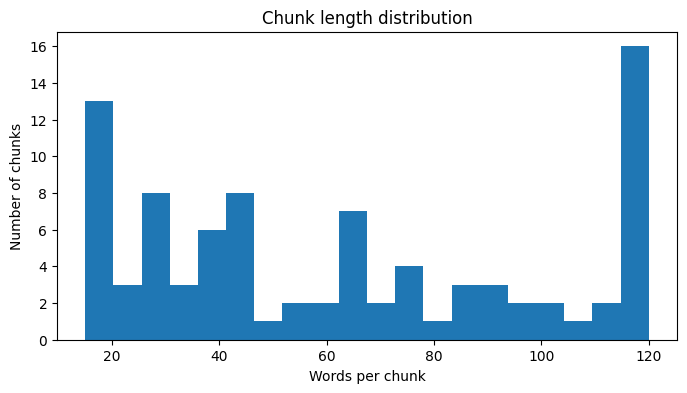

In [10]:
# Check chunk statistics

if len(chunks_df) > 0:
    print(chunks_df["word_count"].describe())

    plt.figure(figsize=(8, 4))
    plt.hist(chunks_df["word_count"], bins=20)
    plt.xlabel("Words per chunk")
    plt.ylabel("Number of chunks")
    plt.title("Chunk length distribution")
    plt.show()

### Reflection field 3: Preprocessing and chunking

Write briefly:

- Which preprocessing steps were applied?
- What chunk size and overlap were used?
- What may happen if the chunk size is too small?
- What may happen if the chunk size is too large?

In [101]:
_ = make_reflection_box(
    key="preprocessing_chunking",
    placeholder="Mention the cleaning steps, chunk size, overlap, and your reasoning. Also describe what may happen when chunks are too small or too large.",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Mention the cleaning steps, chunk…

# 4. TensorFlow TextVectorization

Before building retrieval systems, we first inspect how TensorFlow converts text into token IDs.

This section connects the project with core NLP topics:

- tokenization
- vocabulary creation
- integer encoding
- sequence length
- padding and truncation

In [11]:
# Create a TensorFlow TextVectorization layer

MAX_TOKENS = 5000
SEQUENCE_LENGTH = 60

text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

text_vectorizer.adapt(chunks_df["text"].astype(str).values)

vocab = text_vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocab))
print("First 30 vocabulary items:")
print(vocab[:30])

sample_text = chunks_df.iloc[0]["text"]
vectorized_sample = text_vectorizer(tf.constant([sample_text]))

print("\nSample text:")
print(sample_text[:500])

print("\nVectorized sample shape:", vectorized_sample.shape)
print(vectorized_sample.numpy()[0][:40])

Vocabulary size: 1328
First 30 vocabulary items:
['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('and'), np.str_('of'), np.str_('to'), np.str_('with'), np.str_('is'), np.str_('language'), np.str_('in'), np.str_('tensorflow'), np.str_('natural'), np.str_('courtesy'), np.str_('processing'), np.str_('thushan'), np.str_('second'), np.str_('ganegedara'), np.str_('edition'), np.str_('for'), np.str_('word'), np.str_('words'), np.str_('nlp'), np.str_('as'), np.str_('input'), np.str_('•'), np.str_('state'), np.str_('are'), np.str_('context'), np.str_('that')]

Sample text:
Advanced Intelligent systems Natural Language Processing (NLP) MDM-8 (2 sws/ 3 ects) Introduction-DL Using Tensorflow

Vectorized sample shape: (1, 60)
[ 375 1010  244   12    9   14   22  933   90  424  221 1124 1001   78
   11    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


### Reflection field 4: Text vectorization

Write briefly:

- What does the `TextVectorization` layer do?
- Why do we need a vocabulary?
- What happens when a word is not in the vocabulary?
- Why do we use a fixed sequence length?

In [102]:
_ = make_reflection_box(
    key="text_vectorization",
    placeholder="Explain TextVectorization in simple words. Mention vocabulary, integer sequences, unknown words and fixed input length.",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Explain TextVectorization in simp…

# 5. Small TensorFlow model training

This section is included to understand training behavior.

We train a small classifier that predicts the topic of a text chunk from the lecture slide file name.

This model is not required for the RAG chatbot.  
It is included to study:

- embedding layer
- epochs
- batch size
- training accuracy
- validation accuracy
- overfitting and underfitting

In [12]:
def infer_topic_from_filename(filename: str) -> str:
    name = filename.lower()

    if "embedding" in name or "word" in name:
        return "Embeddings"
    if "transformer" in name or "bert" in name:
        return "Transformers"
    if "lstm" in name:
        return "LSTM"
    if re.search(r"\brnn\b", name) or "rnn" in name:
        return "RNN"
    if "nmt" in name or "seq" in name or "machine translation" in name:
        return "NMT"
    if "intro" in name or "introduction" in name:
        return "Introduction"
    if "tensorflow" in name or "tf" in name:
        return "TensorFlow"
    return "Other"

chunks_df["topic"] = chunks_df["file"].apply(infer_topic_from_filename)

topic_counts = chunks_df["topic"].value_counts()
display(topic_counts.to_frame("number_of_chunks"))

label_names = sorted(chunks_df["topic"].unique())
label_to_id = {label: i for i, label in enumerate(label_names)}
id_to_label = {i: label for label, i in label_to_id.items()}

chunks_df["label"] = chunks_df["topic"].map(label_to_id)

print("Labels:")
print(label_to_id)

,number_of_chunks
topic,
Introduction,31
Embeddings,23
RNN,13
Transformers,11
LSTM,7
NMT,4


Labels:
{'Embeddings': 0, 'Introduction': 1, 'LSTM': 2, 'NMT': 3, 'RNN': 4, 'Transformers': 5}


In [13]:
# Prepare train and validation data

can_train = (chunks_df["label"].nunique() >= 2) and (len(chunks_df) >= 20)

if not can_train:
    print("Not enough labelled chunks to train a meaningful classifier.")
    print("Upload more lecture slide files if you want to run this section.")
else:
    # Stratification works only if each class has at least two samples.
    class_counts = chunks_df["label"].value_counts()
    stratify_values = chunks_df["label"] if class_counts.min() >= 2 else None

    train_df, val_df = train_test_split(
        chunks_df,
        test_size=0.25,
        random_state=SEED,
        stratify=stratify_values
    )

    print("Training samples:", len(train_df))
    print("Validation samples:", len(val_df))
    print("Number of classes:", chunks_df["label"].nunique())

Training samples: 66
Validation samples: 23
Number of classes: 6


In [14]:
def build_small_text_classifier(text_vectorizer, num_classes, embedding_dim=64):
    """A compact TensorFlow model for lecture topic classification."""
    inputs = tf.keras.Input(shape=(1,), dtype=tf.string, name="text")
    x = text_vectorizer(inputs)
    x = layers.Embedding(
        input_dim=len(text_vectorizer.get_vocabulary()),
        output_dim=embedding_dim,
        name="word_embedding"
    )(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

trained_classifier = None
history = None

if can_train:
    trained_classifier = build_small_text_classifier(
        text_vectorizer,
        num_classes=chunks_df["label"].nunique(),
        embedding_dim=64
    )

    trained_classifier.summary()

    history = trained_classifier.fit(
        train_df["text"].astype(str).values,
        train_df["label"].values,
        validation_data=(
            val_df["text"].astype(str).values,
            val_df["label"].values
        ),
        epochs=8,
        batch_size=8,
        verbose=1
    )

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text (InputLayer)               │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 60)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ word_embedding (Embedding)      │ (None, 60, 64)         │        84,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,542 (349.77 KB)

 Trainable params: 89,542 (349.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.2273 - loss: 1.7796 - val_accuracy: 0.4348 - val_loss: 1.7631
Epoch 2/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4848 - loss: 1.7402 - val_accuracy: 0.5217 - val_loss: 1.7330
Epoch 3/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5303 - loss: 1.6875 - val_accuracy: 0.5652 - val_loss: 1.6982
Epoch 4/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5303 - loss: 1.6438 - val_accuracy: 0.5652 - val_loss: 1.6611
Epoch 5/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5303 - loss: 1.5925 - val_accuracy: 0.5652 - val_loss: 1.6265
Epoch 6/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5303 - loss: 1.5375 - val_accuracy: 0.5652 - val_loss: 1.5956
Epoch 7/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5303 - loss: 1.5095 - val_accuracy: 0.5217 - val_loss: 1.5673
Epoch 8/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5455 - loss: 1.4471 - val_accuracy: 0.4783 - val_loss: 1.5374


,accuracy,loss,val_accuracy,val_loss
3,0.530303,1.643843,0.565217,1.661141
4,0.530303,1.592468,0.565217,1.626464
5,0.530303,1.537535,0.565217,1.595618
6,0.530303,1.509541,0.521739,1.567318
7,0.545455,1.447073,0.478261,1.537434


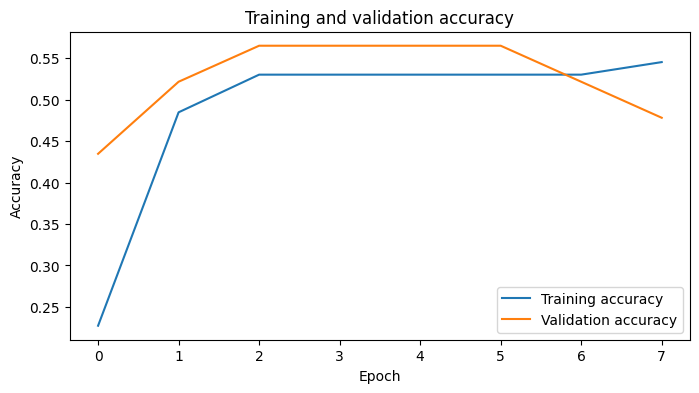

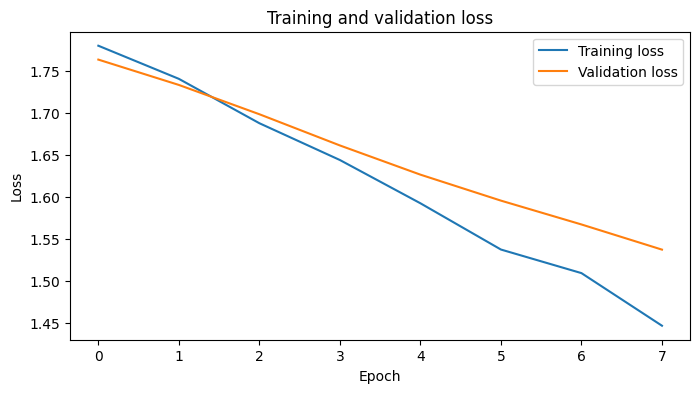

In [15]:
# Plot training history

if history is not None:
    hist = pd.DataFrame(history.history)
    display(hist.tail())

    plt.figure(figsize=(8, 4))
    plt.plot(hist["accuracy"], label="Training accuracy")
    plt.plot(hist["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(hist["loss"], label="Training loss")
    plt.plot(hist["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()

### Reflection field 5: Model training

Write briefly:

- What was the input of the model?
- What was the output label?
- What does the embedding layer learn?
- Did validation accuracy improve with training?
- Did you observe overfitting?

In [103]:
_ = make_reflection_box(
    key="model_training",
    placeholder="Describe the input text chunks, the labels, what the embedding layer learns, and what you observed from training and validation accuracy.",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Describe the input text chunks, t…

# 6. Effect of epochs and batch size

Now we run a small experiment.  
The aim is not to get the highest possible accuracy, but to observe how training settings affect learning.

In [16]:
def run_training_experiment(epochs, batch_size, embedding_dim=64):
    model = build_small_text_classifier(
        text_vectorizer,
        num_classes=chunks_df["label"].nunique(),
        embedding_dim=embedding_dim
    )

    start = time.time()

    hist = model.fit(
        train_df["text"].astype(str).values,
        train_df["label"].values,
        validation_data=(val_df["text"].astype(str).values, val_df["label"].values),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    elapsed = time.time() - start

    return {
        "epochs": epochs,
        "batch_size": batch_size,
        "final_train_accuracy": hist.history["accuracy"][-1],
        "final_val_accuracy": hist.history["val_accuracy"][-1],
        "final_train_loss": hist.history["loss"][-1],
        "final_val_loss": hist.history["val_loss"][-1],
        "training_time_sec": elapsed
    }

experiment_results = []

if can_train:
    configs = [
        {"epochs": 3, "batch_size": 8},
        {"epochs": 8, "batch_size": 8},
        {"epochs": 8, "batch_size": 16},
        {"epochs": 15, "batch_size": 8},
    ]

    for cfg in configs:
        print("Running:", cfg)
        experiment_results.append(run_training_experiment(**cfg))

    experiment_df = pd.DataFrame(experiment_results)
    display(experiment_df)
else:
    print("Skipping experiment because there are not enough labelled chunks.")

Running: {'epochs': 3, 'batch_size': 8}
Running: {'epochs': 8, 'batch_size': 8}
Running: {'epochs': 8, 'batch_size': 16}
Running: {'epochs': 15, 'batch_size': 8}


,epochs,batch_size,final_train_accuracy,final_val_accuracy,final_train_loss,final_val_loss,training_time_sec
0,3,8,0.515152,0.434783,1.730322,1.725332,2.592242
1,8,8,0.560606,0.478261,1.467117,1.548381,2.795398
2,8,16,0.545455,0.565217,1.620117,1.659934,2.321732
3,15,8,0.696970,0.478261,1.065456,1.302576,3.252256


### Reflection field 6: Epochs and batch size

Write briefly:

- What happened when the number of epochs increased?
- Did a larger batch size improve or reduce validation performance?
- Which configuration was most stable?
- What would you try next to improve the model?

In [104]:
_ = make_reflection_box(
    key="epochs_batch_size",
    placeholder="Compare the epoch and batch-size experiments. Which setting looked more stable? Did you observe underfitting or overfitting?",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Compare the epoch and batch-size …

# 7. Inspect learned word embeddings

The classifier has an embedding layer.  
This section shows how words are represented as vectors and how similar words can be found using cosine similarity.

Because the dataset is small, the embeddings may not be perfect.  
The purpose is to understand the idea of embedding space.

In [17]:
def get_embedding_matrix_and_vocab(model, text_vectorizer):
    embedding_layer = model.get_layer("word_embedding")
    embedding_matrix = embedding_layer.get_weights()[0]
    vocabulary = text_vectorizer.get_vocabulary()
    return embedding_matrix, vocabulary

def nearest_words(word, embedding_matrix, vocabulary, top_n=8):
    if word not in vocabulary:
        return pd.DataFrame({"message": [f"'{word}' is not in the vocabulary."]})

    word_index = vocabulary.index(word)
    word_vector = embedding_matrix[word_index]

    norms = np.linalg.norm(embedding_matrix, axis=1) * np.linalg.norm(word_vector)
    similarities = np.dot(embedding_matrix, word_vector) / np.maximum(norms, 1e-9)

    nearest_ids = similarities.argsort()[::-1][1:top_n+1]

    return pd.DataFrame({
        "word": [vocabulary[i] for i in nearest_ids],
        "similarity": [float(similarities[i]) for i in nearest_ids]
    })

if trained_classifier is not None:
    embedding_matrix, vocabulary = get_embedding_matrix_and_vocab(
        trained_classifier,
        text_vectorizer
    )

    print("Embedding matrix shape:", embedding_matrix.shape)

    for query_word in ["transformer", "attention", "lstm", "embedding", "tokenization"]:
        print("\nNearest words for:", query_word)
        display(nearest_words(query_word, embedding_matrix, vocabulary, top_n=8))
else:
    print("Train the classifier first to inspect learned embeddings.")

Embedding matrix shape: (1328, 64)

Nearest words for: transformer


,word,similarity
0,model,0.599618
1,embedding,0.507897
2,positional,0.502008
3,bert,0.471436
4,token,0.470993
5,affinity,0.465265
6,matrix,0.456081
7,when,0.446390



Nearest words for: attention


,word,similarity
0,decoder,0.532083
1,encoder,0.517020
2,found,0.504668
3,outputs,0.496400
4,matrix,0.461278
5,self,0.452613
6,at,0.444328
7,implemented,0.443722



Nearest words for: lstm


,word,similarity
0,state,0.683683
1,cell,0.680716
2,memory,0.586578
3,lstms,0.551054
4,hidden,0.548709
5,thickness,0.544255
6,flows,0.535565
7,internal,0.528757



Nearest words for: embedding


,word,similarity
0,token,0.705964
1,found,0.681082
2,layer,0.623090
3,affinity,0.596619
4,representation,0.587098
5,selfattention,0.583322
6,matrix,0.556624
7,position,0.548673



Nearest words for: tokenization


,word,similarity
0,word2vec,0.585107
1,nlp,0.561939
2,it,0.544466
3,refers,0.528465
4,‚attention,0.523047
5,4,0.512219
6,a,0.510374
7,2020,0.501248


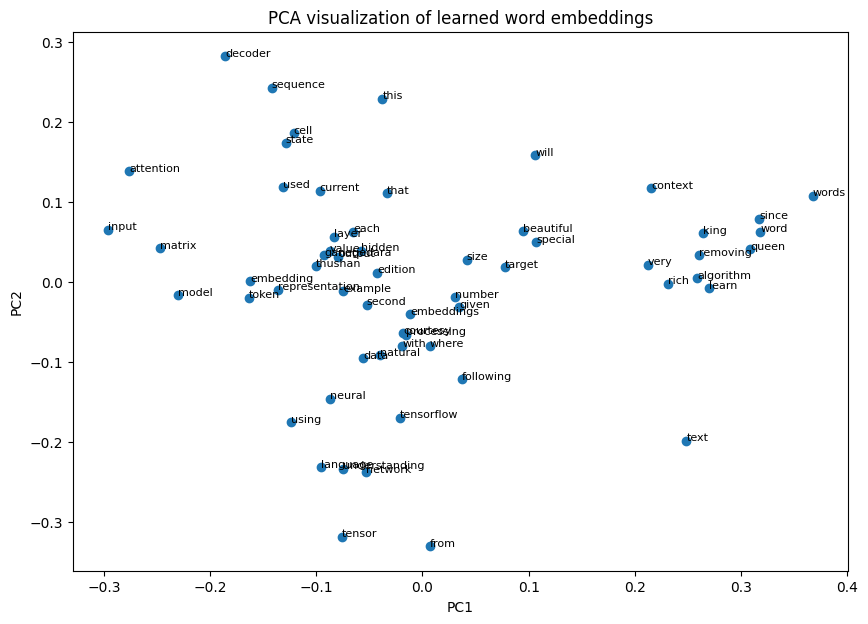

In [18]:
# Optional: visualize a small set of word embeddings with PCA

if trained_classifier is not None:
    words_to_plot = [
        w for w in vocabulary[2:150]
        if w.isalpha() and len(w) > 3
    ][:60]

    if len(words_to_plot) >= 5:
        word_indices = [vocabulary.index(w) for w in words_to_plot]
        selected_vectors = embedding_matrix[word_indices]

        pca = PCA(n_components=2, random_state=SEED)
        coords = pca.fit_transform(selected_vectors)

        plt.figure(figsize=(10, 7))
        plt.scatter(coords[:, 0], coords[:, 1])

        for word, (x, y) in zip(words_to_plot, coords):
            plt.text(x, y, word, fontsize=8)

        plt.title("PCA visualization of learned word embeddings")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.show()
    else:
        print("Not enough words available for visualization.")

### Reflection field 7: Embeddings

Write briefly:

- What is the shape of the embedding matrix?
- Did similar words appear close to each other?
- Why may embeddings trained on a small slide dataset be limited?
- How are these embeddings different from pretrained SentenceTransformer embeddings?

In [105]:
_ = make_reflection_box(
    key="word_embeddings",
    placeholder="Write about the embedding matrix shape and nearest-word examples. Were the similarities meaningful? Why may the result be limited?",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Write about the embedding matrix …

# 8. Conventional chatbot

The conventional system does not use semantic embeddings.

We implement two conventional retrieval options:

1. keyword / regex matching  
2. TF-IDF retrieval  

Both are useful baselines before building a RAG-style system.

In [19]:
def keyword_retrieve(query, chunks_df, top_k=5):
    """Keyword and regex based retrieval."""
    output_columns = ["method", "score", "file", "slide", "text"]

    if chunks_df is None or len(chunks_df) == 0:
        return pd.DataFrame(columns=output_columns)

    query_clean = str(query).lower().strip()
    query_terms = re.findall(r"\b\w+\b", query_clean)
    query_terms = [term for term in query_terms if len(term) > 2]

    results = []

    for _, row in chunks_df.iterrows():
        text_lower = str(row["text"]).lower()
        score = 0

        if query_clean and query_clean in text_lower:
            score += 5

        for term in query_terms:
            score += len(re.findall(r"\b" + re.escape(term) + r"\b", text_lower))

        if score > 0:
            results.append({
                "method": "keyword",
                "score": float(score),
                "file": row["file"],
                "slide": int(row["slide"]),
                "text": row["text"]
            })

    if not results:
        return pd.DataFrame(columns=output_columns)

    return pd.DataFrame(results).sort_values("score", ascending=False).head(top_k)

# TF-IDF model
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(chunks_df["text"].astype(str).values)

def tfidf_retrieve(query, chunks_df, top_k=5):
    """TF-IDF cosine-similarity retrieval."""
    output_columns = ["method", "score", "file", "slide", "text"]

    if chunks_df is None or len(chunks_df) == 0:
        return pd.DataFrame(columns=output_columns)

    top_k = min(top_k, len(chunks_df))
    query_vec = tfidf_vectorizer.transform([str(query)])
    sims = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = sims.argsort()[::-1][:top_k]

    rows = []
    for idx in top_indices:
        row = chunks_df.iloc[int(idx)]
        rows.append({
            "method": "tfidf",
            "score": float(sims[idx]),
            "file": row["file"],
            "slide": int(row["slide"]),
            "text": row["text"]
        })

    return pd.DataFrame(rows, columns=output_columns)

# Quick test
test_query = "Why do transformers need positional encoding?"

print("Keyword retrieval")
display(keyword_retrieve(test_query, chunks_df, top_k=3))

print("TF-IDF retrieval")
display(tfidf_retrieve(test_query, chunks_df, top_k=3))


Keyword retrieval


,method,score,file,slide,text
2,keyword,2.0,6. Transformers.pptx,11,Understanding BERT Courtesy: Natural Language ...
0,keyword,1.0,6. Transformers.pptx,2,Transformers Courtesy: Natural Language Proces...
1,keyword,1.0,6. Transformers.pptx,9,Embedding layers in the Transformer Courtesy: ...


TF-IDF retrieval


,method,score,file,slide,text
0,tfidf,0.116605,6. Transformers.pptx,2,Transformers Courtesy: Natural Language Proces...
1,tfidf,0.114655,6. Transformers.pptx,9,Embedding layers in the Transformer Courtesy: ...
2,tfidf,0.114124,Introduction to NLP Course.pptx,21,"in multiple programming languages, even “trans..."


### Reflection field 8: Conventional retrieval

Write briefly:

- Where does keyword retrieval work well?
- Where does keyword retrieval fail?
- How is TF-IDF better than simple keyword search?
- What is still missing in TF-IDF?

In [106]:
_ = make_reflection_box(
    key="conventional_retrieval",
    placeholder="Explain when keyword/regex and TF-IDF retrieval worked well, when they failed, and why exact wording matters.",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Explain when keyword/regex and TF…

# 9. RAG-style retrieval using SentenceTransformer and FAISS

In this section we build the retrieval part of a RAG system.

The steps are:

1. encode each chunk using a pretrained sentence embedding model  
2. store vectors in a FAISS index  
3. encode the user question  
4. retrieve the most similar chunks  
5. optionally pass those chunks to an LLM API for answer generation  

The LLM API part is optional. The main comparison can be completed using retrieval results alone.

In [20]:
from sentence_transformers import SentenceTransformer
import faiss

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

retrieval_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

chunk_texts = chunks_df["text"].astype(str).tolist()

start = time.time()
chunk_embeddings = retrieval_model.encode(
    chunk_texts,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

# Normalize for cosine similarity using inner product
chunk_embeddings = chunk_embeddings / np.maximum(
    np.linalg.norm(chunk_embeddings, axis=1, keepdims=True),
    1e-9
)

embedding_dim = chunk_embeddings.shape[1]

faiss_index = faiss.IndexFlatIP(embedding_dim)
faiss_index.add(chunk_embeddings)

build_time = time.time() - start

print("Embedding model:", EMBEDDING_MODEL_NAME)
print("Embedding dimension:", embedding_dim)
print("Number of vectors:", faiss_index.ntotal)
print(f"Index build time: {build_time:.2f} seconds")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384
Number of vectors: 89
Index build time: 7.91 seconds


In [21]:
def expand_query(query: str) -> str:
    """Expand short course-specific acronyms for better retrieval.

    This helps with short questions such as "What is RNN?" or "What is BERT?".
    It does not change the displayed user question; it only gives the retriever
    more search context.
    """
    q = str(query)
    q_lower = q.lower()

    expansions = {
        "rnn": "Recurrent Neural Network recurrent neural networks sequential data hidden state memory",
        "lstm": "Long Short-Term Memory gates cell state forget gate input gate output gate vanishing gradient long-term dependency",
        "gru": "Gated Recurrent Unit update gate reset gate recurrent neural network",
        "nmt": "Neural Machine Translation sequence to sequence encoder decoder attention BLEU",
        "bert": "Bidirectional Encoder Representations from Transformers masked language model transformer encoder CLS SEP",
        "tfidf": "TF-IDF term frequency inverse document frequency text vectorization",
        "tf-idf": "TF-IDF term frequency inverse document frequency text vectorization",
        "transformer": "self-attention query key value positional encoding encoder decoder BERT",
        "attention": "attention mechanism weighted average context vector query key value",
        "rag": "Retrieval Augmented Generation retrieval context vector database language model"
    }

    extra_terms = []
    for key, expansion in expansions.items():
        if key in q_lower:
            extra_terms.append(expansion)

    if extra_terms:
        return q + " " + " ".join(extra_terms)
    return q


def semantic_retrieve(query, chunks_df, top_k=5):
    """Semantic retrieval using SentenceTransformer embeddings and FAISS."""
    output_columns = ["method", "score", "file", "slide", "text"]

    if chunks_df is None or len(chunks_df) == 0:
        return pd.DataFrame(columns=output_columns)

    top_k = min(top_k, len(chunks_df))
    expanded_query = expand_query(query)

    query_embedding = retrieval_model.encode(
        [expanded_query],
        convert_to_numpy=True,
        show_progress_bar=False
    ).astype("float32")

    query_embedding = query_embedding / np.maximum(
        np.linalg.norm(query_embedding, axis=1, keepdims=True),
        1e-9
    )

    scores, indices = faiss_index.search(query_embedding, top_k)

    rows = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0:
            continue
        row = chunks_df.iloc[int(idx)]
        rows.append({
            "method": "semantic",
            "score": float(score),
            "file": row["file"],
            "slide": int(row["slide"]),
            "text": row["text"]
        })

    return pd.DataFrame(rows, columns=output_columns)

print("Semantic retrieval")
display(semantic_retrieve(test_query, chunks_df, top_k=3))

print("\nShort acronym query test")
display(semantic_retrieve("What is RNN?", chunks_df, top_k=3))


Semantic retrieval


,method,score,file,slide,text
0,semantic,0.615907,6. Transformers.pptx,11,Understanding BERT Courtesy: Natural Language ...
1,semantic,0.469926,6. Transformers.pptx,9,Embedding layers in the Transformer Courtesy: ...
2,semantic,0.456013,6. Transformers.pptx,6,Self Attention Layer Courtesy: Natural Languag...



Short acronym query test


,method,score,file,slide,text
0,semantic,0.652648,3. RNN.pptx,2,Recurrent Neural networks Courtesy: Natural La...
1,semantic,0.561678,4. LSTM.pptx,2,LSTM Courtesy: Natural Language Processing wit...
2,semantic,0.560668,4. LSTM.pptx,3,LSTM- Basic Architecture Courtesy: Natural Lan...


In [22]:
def build_rag_prompt(query, retrieved_df):
    """Build a compact RAG prompt from retrieved context."""
    context_blocks = []

    for _, row in retrieved_df.iterrows():
        context_blocks.append(
            f"Source: {row['file']}, Slide {row['slide']}\n{row['text']}"
        )

    context = "\n\n".join(context_blocks)

    prompt = f"""
Answer the question using only the lecture slide context below.
Do not add outside information.
If the context only partly answers the question, answer the available part and clearly say what is missing.
If the answer cannot be found at all, say that it is not available in the lecture slides.
Mention the relevant source slides at the end.

Context:
{context}

Question:
{query}

Answer:
"""

    return prompt.strip()

retrieved = semantic_retrieve(test_query, chunks_df, top_k=3)
print(build_rag_prompt(test_query, retrieved)[:2000])


Answer the question using only the lecture slide context below.
Do not add outside information.
If the context only partly answers the question, answer the available part and clearly say what is missing.
If the answer cannot be found at all, say that it is not available in the lecture slides.
Mention the relevant source slides at the end.

Context:
Source: 6. Transformers.pptx, Slide 11
Understanding BERT Courtesy: Natural Language Processing with TensorFlow Second Edition, Thushan Ganegedara Bidirectional Encoder Representation from Transformers BERT is an encoder-based Transformer BERT outputs a hidden representation for every token in the input sequence BERT has three embedding spaces: token embedding, positional embedding, and segment embedding The segment embedding provides a distinct representation for each sub-component in the input, when the input consists of multiple components BERT uses a special token [CLS] to denote the beginning of an input and is used as the input to a do

In [23]:
# Optional LLM answer generation using Gemini API.
# Keep USE_GEMINI = False unless you have an API key and want to test generated answers.

USE_GEMINI = False
GEMINI_API_KEY = "PASTE_API_KEY_HERE"
GEMINI_MODEL = "gemini-2.5-flash"

def generate_rag_answer_optional(query, top_k=3):
    retrieved_df = semantic_retrieve(query, chunks_df, top_k=top_k)
    prompt = build_rag_prompt(query, retrieved_df)

    if not USE_GEMINI:
        return {
            "answer": "LLM generation is disabled. Use the retrieved context shown below.",
            "retrieved": retrieved_df,
            "prompt": prompt
        }

    from google import genai
    client = genai.Client(api_key=GEMINI_API_KEY)

    response = client.models.generate_content(
        model=GEMINI_MODEL,
        contents=prompt
    )

    return {
        "answer": response.text,
        "retrieved": retrieved_df,
        "prompt": prompt
    }

rag_result = generate_rag_answer_optional(test_query, top_k=3)
print(rag_result["answer"])
display(rag_result["retrieved"])

LLM generation is disabled. Use the retrieved context shown below.


,method,score,file,slide,text
0,semantic,0.615907,6. Transformers.pptx,11,Understanding BERT Courtesy: Natural Language ...
1,semantic,0.469926,6. Transformers.pptx,9,Embedding layers in the Transformer Courtesy: ...
2,semantic,0.456013,6. Transformers.pptx,6,Self Attention Layer Courtesy: Natural Languag...


### Reflection field 9: RAG retrieval

Write briefly:

- Which embedding model was used?
- What is the role of FAISS?
- Why can semantic retrieval find relevant slides even when exact keywords are missing?
- Why should a RAG answer include source slides?

In [107]:
_ = make_reflection_box(
    key="rag_retrieval",
    placeholder="Explain the embedding model, FAISS, top-k retrieval and why semantic search can find slides even with different wording.",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Explain the embedding model, FAIS…

# 10. Launch Streamlit UI

This UI is launched **in the background** so that the notebook can continue running after the app is opened.  
Use it for visual testing before completing the manual benchmark and reflection fields.

The app avoids a few Streamlit widgets that can be unstable through Colab tunnels, such as `st.metric` and some sliders. It uses simple text output and number inputs instead.


In [24]:
%%writefile app.py
import re
import time
import numpy as np
import pandas as pd
import streamlit as st

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
import faiss

st.set_page_config(page_title="NLP Lecture Slide Chatbot", layout="wide")

st.title("NLP Lecture Slide Chatbot")
st.caption("Conventional retrieval and RAG-style retrieval using lecture slide chunks")

@st.cache_data
def load_chunks(path="lecture_chunks.csv"):
    return pd.read_csv(path)

@st.cache_resource
def load_embedding_model(model_name):
    return SentenceTransformer(model_name)

@st.cache_resource
def build_semantic_index(texts, model_name):
    model = load_embedding_model(model_name)
    embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False).astype("float32")
    embeddings = embeddings / np.maximum(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-9)
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    return model, index

@st.cache_resource
def build_tfidf(texts):
    vectorizer = TfidfVectorizer(lowercase=True, stop_words="english", max_features=5000)
    matrix = vectorizer.fit_transform(texts)
    return vectorizer, matrix

def expand_query(query: str) -> str:
    """Expand short course acronyms for more stable retrieval."""
    q = str(query)
    q_lower = q.lower()
    expansions = {
        "rnn": "Recurrent Neural Network recurrent neural networks sequential data hidden state memory",
        "lstm": "Long Short-Term Memory gates cell state forget gate input gate output gate vanishing gradient long-term dependency",
        "gru": "Gated Recurrent Unit update gate reset gate recurrent neural network",
        "nmt": "Neural Machine Translation sequence to sequence encoder decoder attention BLEU",
        "bert": "Bidirectional Encoder Representations from Transformers masked language model transformer encoder CLS SEP",
        "tfidf": "TF-IDF term frequency inverse document frequency text vectorization",
        "tf-idf": "TF-IDF term frequency inverse document frequency text vectorization",
        "transformer": "self-attention query key value positional encoding encoder decoder BERT",
        "attention": "attention mechanism weighted average context vector query key value",
        "rag": "Retrieval Augmented Generation retrieval context vector database language model"
    }
    extra_terms = []
    for key, expansion in expansions.items():
        if key in q_lower:
            extra_terms.append(expansion)
    if extra_terms:
        return q + " " + " ".join(extra_terms)
    return q

def keyword_retrieve(query, chunks_df, top_k):
    output_columns = ["score", "file", "slide", "text"]
    query_clean = str(query).lower().strip()
    query_terms = re.findall(r"\b\w+\b", query_clean)
    query_terms = [term for term in query_terms if len(term) > 2]

    results = []
    for _, row in chunks_df.iterrows():
        text_lower = str(row["text"]).lower()
        score = 0

        if query_clean and query_clean in text_lower:
            score += 5

        for term in query_terms:
            score += len(re.findall(r"\b" + re.escape(term) + r"\b", text_lower))

        if score > 0:
            results.append({
                "score": float(score),
                "file": row["file"],
                "slide": int(row["slide"]),
                "text": row["text"]
            })

    if not results:
        return pd.DataFrame(columns=output_columns)

    return pd.DataFrame(results).sort_values("score", ascending=False).head(top_k)

def tfidf_retrieve(query, chunks_df, vectorizer, matrix, top_k):
    output_columns = ["score", "file", "slide", "text"]
    top_k = min(top_k, len(chunks_df))
    query_vec = vectorizer.transform([str(query)])
    sims = cosine_similarity(query_vec, matrix).flatten()
    top_indices = sims.argsort()[::-1][:top_k]

    rows = []
    for idx in top_indices:
        row = chunks_df.iloc[int(idx)]
        rows.append({
            "score": float(sims[idx]),
            "file": row["file"],
            "slide": int(row["slide"]),
            "text": row["text"]
        })

    return pd.DataFrame(rows, columns=output_columns)

def semantic_retrieve(query, chunks_df, model, index, top_k):
    output_columns = ["score", "file", "slide", "text"]
    top_k = min(top_k, len(chunks_df))
    expanded_query = expand_query(query)
    q = model.encode([expanded_query], convert_to_numpy=True, show_progress_bar=False).astype("float32")
    q = q / np.maximum(np.linalg.norm(q, axis=1, keepdims=True), 1e-9)
    scores, indices = index.search(q, top_k)

    rows = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0:
            continue
        row = chunks_df.iloc[int(idx)]
        rows.append({
            "score": float(score),
            "file": row["file"],
            "slide": int(row["slide"]),
            "text": row["text"]
        })

    return pd.DataFrame(rows, columns=output_columns)

def build_prompt(query, retrieved_df):
    context = "\n\n".join(
        [f"Source: {r.file}, Slide {r.slide}\n{r.text}" for r in retrieved_df.itertuples()]
    )

    return f"""
Answer the question using only the lecture slide context below.
Do not add outside information.
If the context only partly answers the question, answer the available part and clearly say what is missing.
If the answer cannot be found at all, say that it is not available in the lecture slides.
Mention the relevant source slides at the end.

Context:
{context}

Question:
{query}

Answer:
""".strip()

def generate_gemini_answer(prompt, api_key, model_name):
    if not api_key:
        return "No API key provided. Showing retrieved context only."

    try:
        from google import genai
        client = genai.Client(api_key=api_key)
        response = client.models.generate_content(model=model_name, contents=prompt)
        return response.text
    except Exception as e:
        return f"LLM generation failed: {e}"

try:
    chunks_df = load_chunks()
except Exception:
    st.error("lecture_chunks.csv was not found. Run the notebook cells up to chunk creation first.")
    st.stop()

if chunks_df.empty or "text" not in chunks_df.columns:
    st.error("The chunk file is empty or invalid. Re-run the chunk creation cell.")
    st.stop()

texts = chunks_df["text"].astype(str).tolist()

st.sidebar.header("Settings")

method = st.sidebar.radio(
    "Retrieval method",
    ["Keyword / Regex", "TF-IDF", "Semantic Retrieval / RAG"]
)

max_k = max(1, min(10, len(chunks_df)))
default_k = min(3, max_k)
top_k = st.sidebar.number_input(
    "Top-k results",
    min_value=1,
    max_value=max_k,
    value=default_k,
    step=1
)
top_k = int(top_k)

embedding_model_name = st.sidebar.selectbox(
    "Embedding model",
    ["sentence-transformers/all-MiniLM-L6-v2", "BAAI/bge-small-en-v1.5"]
)

st.sidebar.header("Optional LLM generation")
use_llm = st.sidebar.checkbox("Generate answer using Gemini API", value=False)
api_key = st.sidebar.text_input("Gemini API key", type="password")
gemini_model = st.sidebar.text_input("Gemini model", value="gemini-2.5-flash")

st.subheader("Dataset overview")
st.markdown(
    f"""
- **Text chunks:** {len(chunks_df)}
- **Source files:** {chunks_df['file'].nunique()}
- **Slides with extracted text:** {chunks_df[['file', 'slide']].drop_duplicates().shape[0]}
"""
)

query = st.text_input(
    "Ask a question from the lecture slides",
    placeholder="Example: What are Recurrent Neural Networks and how do they process sequential data?"
)

if st.button("Search"):
    if not query.strip():
        st.warning("Please enter a question.")
        st.stop()

    start = time.time()

    if method == "Keyword / Regex":
        results = keyword_retrieve(query, chunks_df, top_k)

    elif method == "TF-IDF":
        tfidf_vectorizer, tfidf_matrix = build_tfidf(texts)
        results = tfidf_retrieve(query, chunks_df, tfidf_vectorizer, tfidf_matrix, top_k)

    else:
        model, index = build_semantic_index(texts, embedding_model_name)
        results = semantic_retrieve(query, chunks_df, model, index, top_k)

    elapsed = time.time() - start

    st.write(f"Response time: {elapsed:.3f} seconds")

    if results.empty:
        st.warning("No result found.")
        st.stop()

    if method == "Semantic Retrieval / RAG" and use_llm:
        prompt = build_prompt(query, results)
        answer = generate_gemini_answer(prompt, api_key, gemini_model)
        st.subheader("Generated answer")
        st.write(answer)

    st.subheader("Retrieved sources")
    for i, row in enumerate(results.itertuples(), start=1):
        with st.expander(f"Rank {i} | Score {row.score:.4f} | {row.file} | Slide {row.slide}"):
            st.write(row.text)

st.divider()
st.subheader("Use this UI for reflection")
st.write(
    "Try the same question with different methods and top-k values. "
    "Record where conventional retrieval fails and where semantic retrieval improves the result. "
    "For short acronyms such as RNN, LSTM, NMT, or BERT, the semantic retriever expands the query internally."
)


Writing app.py


In [88]:
# Start Streamlit in the background.
# This cell will finish quickly, so you can continue running the notebook.

!pkill -f streamlit || true
!streamlit run app.py --server.port 9000 --server.address 0.0.0.0 --server.headless true > streamlit_new.log 2>&1 &

import time
print("Starting Streamlit in the background...")
time.sleep(4)
print("Streamlit is running. Open it using the next cell.")

^C
Starting Streamlit in the background...
Streamlit is running. Open it using the next cell.


In [89]:
!streamlit run app.py \
  --server.port 9000 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit_new.log 2>&1 &

import time
time.sleep(8)

print("Streamlit started. Checking log...")
!tail -n 40 streamlit_new.log

Streamlit started. Checking log...


2026-06-19 12:53:05.799 Uvicorn server started on 127.0.0.1:9000

  You can now view your Streamlit app in your browser.

  URL: http://127.0.0.1:9000



In [90]:
from google.colab import output
output.serve_kernel_port_as_iframe(9000, width="100%", height=850)

<IPython.core.display.Javascript object>

In [91]:
from google.colab import output
output.serve_kernel_port_as_window(9000)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [92]:
# Open the Streamlit app in a new Colab window.
# The notebook remains usable after this cell.

from google.colab import output
output.serve_kernel_port_as_window(9000)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [93]:
# Optional: show the Streamlit app inside the notebook instead of a separate window.

from google.colab import output
output.serve_kernel_port_as_iframe(9000, width="100%", height=800)

<IPython.core.display.Javascript object>

### Reflection field 10: UI experience

Write briefly:

- Did the UI make the chatbot easier to test?
- Which method looked more useful from a user point of view?
- What additional UI feature would improve the application?

In [108]:
_ = make_reflection_box(
    key="ui_experience",
    placeholder="Describe whether the Streamlit UI made the chatbot easier to test. What did you like, and what would you improve?",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Describe whether the Streamlit UI…

# 11. Manual comparison after UI testing

Now test the methods in the notebook so that results can be recorded.

Use the same questions for all methods.

In [33]:
test_questions = [
    "What is NLP?",
    "What is tokenization?",
    "What is TF-IDF?",
    "Why do RNNs need memory?",
    "How does LSTM handle long-term dependency?",
    "What is attention in NMT?",
    "What is self-attention?",
    "What are query, key and value?",
    "Why do transformers need positional encoding?",
    "What is BERT?"
]

def compare_methods_for_query(query, top_k=3):
    rows = []

    for method_name, func in [
        ("keyword", lambda q: keyword_retrieve(q, chunks_df, top_k=top_k)),
        ("tfidf", lambda q: tfidf_retrieve(q, chunks_df, top_k=top_k)),
        ("semantic", lambda q: semantic_retrieve(q, chunks_df, top_k=top_k)),
    ]:
        start = time.time()
        result_df = func(query)
        elapsed = time.time() - start

        if len(result_df) == 0:
            rows.append({
                "question": query,
                "method": method_name,
                "rank": None,
                "score": None,
                "file": None,
                "slide": None,
                "text": None,
                "response_time_sec": elapsed
            })
        else:
            for rank, row in enumerate(result_df.itertuples(), start=1):
                rows.append({
                    "question": query,
                    "method": method_name,
                    "rank": rank,
                    "score": row.score,
                    "file": row.file,
                    "slide": row.slide,
                    "text": row.text,
                    "response_time_sec": elapsed
                })

    return pd.DataFrame(rows)

comparison_results = pd.concat(
    [compare_methods_for_query(q, top_k=3) for q in test_questions],
    ignore_index=True
)

display(comparison_results.head(15))
comparison_results.to_csv("retrieval_comparison_results.csv", index=False)
print("Saved: retrieval_comparison_results.csv")

,question,method,rank,score,file,slide,text,response_time_sec
0,What is NLP?,keyword,1,8.000000,2. Word Embeddings.pptx,3,"Data Preprocessing Eg: ""I've been studying NLP...",0.012370
1,What is NLP?,keyword,2,4.000000,2. Word Embeddings.pptx,3,"""nlp"", ""since"", ""2020"", ""excite"", ""learn"", ""lo...",0.012370
2,What is NLP?,keyword,3,4.000000,Introduction to NLP Course.pptx,13,NLP in History 1950s-1970s: Rule-based NLP sys...,0.012370
3,What is NLP?,tfidf,1,0.513262,1. Introduction to NLP with TF.pptx,3,Tasks in NLP Fig: Sample NLP Hierarchy Courtes...,0.005530
4,What is NLP?,tfidf,2,0.437220,1. Introduction to NLP with TF.pptx,4,Classical NLP Approach Fig: Classical NLP for ...,0.005530
5,What is NLP?,tfidf,3,0.432991,Introduction to NLP Course.pptx,3,COURSE OBJECTIVES Understand fundamental and a...,0.005530
6,What is NLP?,semantic,1,0.816957,Introduction to NLP Course.pptx,4,NLP! WIKI: NATURAL LANGUAGE PROCESSING (NLP) I...,0.024824
7,What is NLP?,semantic,2,0.804951,Introduction to NLP Course.pptx,5,NLP! Natural Language Processing (NLP) is a mu...,0.024824
8,What is NLP?,semantic,3,0.572048,Introduction to NLP Course.pptx,12,Possibilities and Challenges Go beyond Keyword...,0.024824
9,What is tokenization?,keyword,1,1.000000,1. Introduction to NLP with TF.pptx,2,Tasks in NLP Tokenization Word-Sense Disambigu...,0.010569


Saved: retrieval_comparison_results.csv


# 12. Manual relevance marking and metrics

For a classroom exercise, students can manually judge whether each retrieved chunk is relevant.

Use a simple relevance value:

- `1` = relevant  
- `0` = not relevant  

This makes the evaluation transparent and easy to discuss.

In [34]:
# Create a manual evaluation template.
# You can download it, fill relevance_0_or_1, and upload it again if desired.

manual_eval_template = comparison_results.copy()
manual_eval_template["relevance_0_or_1"] = ""

manual_eval_template.to_csv("manual_evaluation_template.csv", index=False)

display(manual_eval_template[[
    "question", "method", "rank", "score", "file", "slide", "relevance_0_or_1"
]].head(30))

print("Saved: manual_evaluation_template.csv")

,question,method,rank,score,file,slide,relevance_0_or_1
0,What is NLP?,keyword,1,8.000000,2. Word Embeddings.pptx,3,
1,What is NLP?,keyword,2,4.000000,2. Word Embeddings.pptx,3,
2,What is NLP?,keyword,3,4.000000,Introduction to NLP Course.pptx,13,
3,What is NLP?,tfidf,1,0.513262,1. Introduction to NLP with TF.pptx,3,
4,What is NLP?,tfidf,2,0.437220,1. Introduction to NLP with TF.pptx,4,
5,What is NLP?,tfidf,3,0.432991,Introduction to NLP Course.pptx,3,
6,What is NLP?,semantic,1,0.816957,Introduction to NLP Course.pptx,4,
7,What is NLP?,semantic,2,0.804951,Introduction to NLP Course.pptx,5,
8,What is NLP?,semantic,3,0.572048,Introduction to NLP Course.pptx,12,
9,What is tokenization?,keyword,1,1.000000,1. Introduction to NLP with TF.pptx,2,


Saved: manual_evaluation_template.csv


In [35]:
def precision_at_k(relevance_flags, k):
    flags = list(relevance_flags)[:k]
    if len(flags) == 0:
        return 0.0
    return sum(flags) / k

def reciprocal_rank(relevance_flags):
    for i, flag in enumerate(relevance_flags, start=1):
        if flag == 1:
            return 1 / i
    return 0.0

# Example calculation
example_flags = [0, 1, 0]
print("Example Precision@3:", precision_at_k(example_flags, 3))
print("Example Reciprocal Rank:", reciprocal_rank(example_flags))

Example Precision@3: 0.3333333333333333
Example Reciprocal Rank: 0.5


In [36]:
# After filling manual_evaluation_template.csv, upload the completed file here.
# The completed file must contain the column relevance_0_or_1 with 0/1 values.

# Uncomment this when you have a completed file:
# uploaded_eval = files.upload()
# eval_file = list(uploaded_eval.keys())[0]
# eval_df = pd.read_csv(eval_file)

# Temporary placeholder: copy template and mark relevance manually inside Colab if desired.
eval_df = manual_eval_template.copy()

# If you manually edit eval_df in code, make sure the relevance column contains numbers.
display(eval_df.head())

,question,method,rank,score,file,slide,text,response_time_sec,relevance_0_or_1
0,What is NLP?,keyword,1,8.000000,2. Word Embeddings.pptx,3,"Data Preprocessing Eg: ""I've been studying NLP...",0.01237,
1,What is NLP?,keyword,2,4.000000,2. Word Embeddings.pptx,3,"""nlp"", ""since"", ""2020"", ""excite"", ""learn"", ""lo...",0.01237,
2,What is NLP?,keyword,3,4.000000,Introduction to NLP Course.pptx,13,NLP in History 1950s-1970s: Rule-based NLP sys...,0.01237,
3,What is NLP?,tfidf,1,0.513262,1. Introduction to NLP with TF.pptx,3,Tasks in NLP Fig: Sample NLP Hierarchy Courtes...,0.00553,
4,What is NLP?,tfidf,2,0.437220,1. Introduction to NLP with TF.pptx,4,Classical NLP Approach Fig: Classical NLP for ...,0.00553,


In [37]:
def summarize_manual_metrics(eval_df, k=3):
    df = eval_df.copy()

    if "relevance_0_or_1" not in df.columns:
        raise ValueError("Missing relevance_0_or_1 column.")

    df = df[df["relevance_0_or_1"].astype(str).str.strip() != ""].copy()

    if len(df) == 0:
        print("No relevance values filled yet. Complete manual evaluation first.")
        return None

    df["relevance_0_or_1"] = df["relevance_0_or_1"].astype(int)

    summaries = []

    for (question, method), group in df.groupby(["question", "method"]):
        group = group.sort_values("rank")
        flags = group["relevance_0_or_1"].tolist()

        summaries.append({
            "question": question,
            "method": method,
            f"precision_at_{k}": precision_at_k(flags, k),
            "reciprocal_rank": reciprocal_rank(flags),
            "avg_response_time_sec": group["response_time_sec"].mean()
        })

    summary_df = pd.DataFrame(summaries)

    overall = (
        summary_df
        .groupby("method")
        .agg(
            mean_precision_at_k=(f"precision_at_{k}", "mean"),
            std_precision_at_k=(f"precision_at_{k}", "std"),
            mean_mrr=("reciprocal_rank", "mean"),
            mean_response_time_sec=("avg_response_time_sec", "mean")
        )
        .reset_index()
    )

    return summary_df, overall

# Run after relevance values are filled.
metric_result = summarize_manual_metrics(eval_df, k=3)

if metric_result is not None:
    question_level_metrics, overall_metrics = metric_result
    display(question_level_metrics)
    display(overall_metrics)

No relevance values filled yet. Complete manual evaluation first.


### Reflection field 11: Manual evaluation

Write briefly:

- Which method retrieved more relevant chunks?
- Did the semantic method always outperform the conventional method?
- Which type of question was difficult for all methods?
- Which metric was most useful: Precision@3, reciprocal rank, or response time?

In [109]:
_ = make_reflection_box(
    key="manual_evaluation",
    placeholder="Compare the methods using your test questions. Which method retrieved better chunks? Which question type was difficult?",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Compare the methods using your te…

# 13. Optimization study

Try changing:

- chunk size
- overlap
- top-k
- embedding model
- number of epochs
- batch size

For a two-session exercise, use small experiments rather than many combinations.

In [38]:
# Simple retrieval-time comparison for different top-k values

topk_rows = []
sample_query = "What is self-attention?"

for k in [1, 3, 5, 8]:
    start = time.time()
    result = semantic_retrieve(sample_query, chunks_df, top_k=k)
    elapsed = time.time() - start

    topk_rows.append({
        "top_k": k,
        "response_time_sec": elapsed,
        "top_result_file": result.iloc[0]["file"] if len(result) else None,
        "top_result_slide": result.iloc[0]["slide"] if len(result) else None,
        "top_score": result.iloc[0]["score"] if len(result) else None
    })

topk_df = pd.DataFrame(topk_rows)
display(topk_df)

,top_k,response_time_sec,top_result_file,top_result_slide,top_score
0,1,0.026807,6. Transformers.pptx,6,0.669163
1,3,0.021356,6. Transformers.pptx,6,0.669163
2,5,0.022244,6. Transformers.pptx,6,0.669163
3,8,0.022585,6. Transformers.pptx,6,0.669163


In [39]:
# Chunk-size experiment.
# This rebuilds chunks and the semantic index for a few chunk sizes.
# For quality, inspect the top result manually.

def build_index_for_chunks(temp_chunks_df, model):
    texts = temp_chunks_df["text"].astype(str).tolist()
    vectors = model.encode(texts, convert_to_numpy=True, show_progress_bar=False).astype("float32")
    vectors = vectors / np.maximum(np.linalg.norm(vectors, axis=1, keepdims=True), 1e-9)
    index = faiss.IndexFlatIP(vectors.shape[1])
    index.add(vectors)
    return index, vectors

def semantic_retrieve_from_temp(query, temp_chunks_df, model, index, top_k=3):
    output_columns = ["score", "file", "slide", "text"]

    if temp_chunks_df is None or len(temp_chunks_df) == 0:
        return pd.DataFrame(columns=output_columns)

    top_k = min(top_k, len(temp_chunks_df))
    q = model.encode([str(query)], convert_to_numpy=True, show_progress_bar=False).astype("float32")
    q = q / np.maximum(np.linalg.norm(q, axis=1, keepdims=True), 1e-9)
    scores, indices = index.search(q, top_k)

    rows = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0:
            continue
        row = temp_chunks_df.iloc[int(idx)]
        rows.append({
            "score": float(score),
            "file": row["file"],
            "slide": int(row["slide"]),
            "text": row["text"]
        })
    return pd.DataFrame(rows, columns=output_columns)

chunk_experiment_rows = []
sample_query = "Why do transformers need positional encoding?"

for size in [60, 120, 200]:
    temp_chunks = create_chunks(
        slides_df,
        chunk_size=size,
        overlap=min(30, size // 4),
        min_words=10
    )

    if len(temp_chunks) == 0:
        chunk_experiment_rows.append({
            "chunk_size": size,
            "number_of_chunks": 0,
            "index_build_time_sec": None,
            "top_result_file": None,
            "top_result_slide": None,
            "top_score": None,
            "top_text_preview": None
        })
        continue

    start = time.time()
    temp_index, _ = build_index_for_chunks(temp_chunks, retrieval_model)
    build_elapsed = time.time() - start

    result = semantic_retrieve_from_temp(
        sample_query,
        temp_chunks,
        retrieval_model,
        temp_index,
        top_k=3
    )

    chunk_experiment_rows.append({
        "chunk_size": size,
        "number_of_chunks": len(temp_chunks),
        "index_build_time_sec": build_elapsed,
        "top_result_file": result.iloc[0]["file"] if len(result) else None,
        "top_result_slide": result.iloc[0]["slide"] if len(result) else None,
        "top_score": result.iloc[0]["score"] if len(result) else None,
        "top_text_preview": result.iloc[0]["text"][:250] if len(result) else None
    })

chunk_experiment_df = pd.DataFrame(chunk_experiment_rows)
display(chunk_experiment_df)


,chunk_size,number_of_chunks,index_build_time_sec,top_result_file,top_result_slide,top_score,top_text_preview
0,60,161,10.107203,6. Transformers.pptx,11,0.419472,Understanding BERT Courtesy: Natural Language ...
1,120,108,8.606101,6. Transformers.pptx,9,0.412080,Embedding layers in the Transformer Courtesy: ...
2,200,96,6.620333,6. Transformers.pptx,9,0.412080,Embedding layers in the Transformer Courtesy: ...


### Reflection field 12: Optimization

Write briefly:

- Which chunk size worked best?
- Which top-k value was most useful?
- Did longer chunks provide better answers or more noise?
- What would you optimize if this system were used for many lecture modules?

In [110]:
_ = make_reflection_box(
    key="optimization",
    placeholder="Mention the best chunk size/top-k you tested, the trade-off between answer quality and response time, and one future improvement.",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Mention the best chunk size/top-k…

# 14. Final reflection

Complete the final reflection in your own words.

Recommended length: 150–250 words.

In [111]:
_ = make_reflection_box(
    key="final_reflection",
    placeholder="Write 150–250 words in your own words. Include what was developed, preprocessing, model training observations, retrieval comparison, UI experience and improvements.",
    height="190px"
)


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Write 150–250 words in your own w…

In [114]:
# Export reflection text-box answers to a Markdown file

from google.colab import files

reflection_notes = collect_reflections()


def export_reflection_notes(reflection_notes, output_path="student_reflection_notes.md"):
    lines = []
    lines.append("# NLP Lecture Slide Retrieval Project - Reflection Notes\n")
    lines.append("Student name: ____________________\n")
    lines.append("Group number: ____________________\n")
    lines.append("\n---\n")

    if not reflection_notes:
        lines.append("No reflection boxes were found. Please run the reflection cells first.\n")
    else:
        for key, value in reflection_notes.items():
            title = key.replace("_", " ").title()
            lines.append(f"## {title}\n")
            if value:
                lines.append(value + "\n")
            else:
                lines.append("[No answer entered.]\n")

    with open(output_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    return output_path

reflection_file = export_reflection_notes(reflection_notes)
print("Saved:", reflection_file)
files.download(reflection_file)



Saved: student_reflection_notes.md


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
# Optional: stop the Streamlit app after finishing the notebook.

!pkill -f streamlit || true
print("Streamlit app stopped.")

^C
Streamlit app stopped.


# End of notebook

You have completed the full workflow:

- slide dataset preparation  
- text extraction  
- preprocessing and chunking  
- TensorFlow text vectorization  
- small model training  
- word embedding inspection  
- conventional retrieval  
- RAG-style retrieval  
- Streamlit UI testing  
- benchmarking and reflection  

The notebook can now be submitted together with the completed reflection notes and evaluation table.